# E1 — Feature Engineering y Análisis Exploratorio
## Proyecto Final Trading — UAI Magíster Finanzas
### Opción 2: Sistema de Trading Sistemático con Señales de ML
**Activo:** SPY (S&P 500 ETF) | **Horizonte predicción:** 5 días | **Fuente:** Yahoo Finance + FRED API

---
**Pipeline del proyecto:**
1. ✅ Datos y features ← *Este notebook*
2. Target y labels ← *Este notebook*
3. Entrenamiento ML ← Notebook E2
4. Walk-forward validation ← Notebook E2
5. Backtest + costos ← Notebook E2

**Supuestos de data cleaning:**
- Datos OHLCV ajustados por splits y dividendos (`auto_adjust=True`)
- Forward fill para datos macro en días sin dato (fines de semana, feriados)
- Se eliminan las primeras ~200 observaciones por warmup de indicadores (SMA200)
- Se eliminan las últimas 5 observaciones (sin retorno futuro disponible)
- **La normalización NO se aplica aquí** — se aplica dentro de cada fold en E2 para evitar data leakage


## 0. Configuración e imports

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import json
from datetime import datetime

# Intentar FRED API (opcional — si falla, se usan proxies)
try:
    from fredapi import Fred
    FRED_DISPONIBLE = True
except ImportError:
    FRED_DISPONIBLE = False
    print("⚠ fredapi no instalado. Instalar con: pip install fredapi")

# ── PARÁMETROS GLOBALES ──
TICKER      = "SPY"
START_DATE  = "2015-01-01"
END_DATE    = datetime.today().strftime("%Y-%m-%d")
HORIZONTE   = 5          # días para el target
FRED_KEY    = "f8e46e1ef4d18aaac1a83ec4c7e7ba85"  # clave pública demo FRED

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.6f}'.format)

print(f"Configuración: {TICKER} | {START_DATE} → {END_DATE} | Horizonte: {HORIZONTE}d")
print(f"FRED API disponible: {FRED_DISPONIBLE}")


Configuración: SPY | 2015-01-01 → 2026-04-29 | Horizonte: 5d
FRED API disponible: True


## 1. [D1-2] Adquisición de datos — OHLCV desde Yahoo Finance

In [3]:
print("📥 Descargando datos OHLCV...")
raw = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)
raw.columns = [c[0] if isinstance(c, tuple) else c for c in raw.columns]
raw.index = pd.to_datetime(raw.index)
raw = raw[['Open','High','Low','Close','Volume']].dropna()

print(f"✓ {len(raw):,} observaciones | {raw.index[0].date()} → {raw.index[-1].date()}")
print(f"✓ NaN en OHLCV: {raw.isnull().sum().sum()}")
print(f"✓ Precio inicial: ${raw['Close'].iloc[0]:.2f} | Precio actual: ${raw['Close'].iloc[-1]:.2f}")
raw.tail(3)


📥 Descargando datos OHLCV...
✓ 2,846 observaciones | 2015-01-02 → 2026-04-28
✓ NaN en OHLCV: 0
✓ Precio inicial: $170.13 | Precio actual: $711.69


,Open,High,Low,Close,Volume
Date,,,,,
2026-04-24,710.750000,714.469971,709.010010,713.940002,45182000
2026-04-27,713.169983,715.630005,712.299988,715.169983,33135900
2026-04-28,711.820007,712.880005,709.250000,711.690002,43066700


## 2. [D1-2] Datos macro — VIX y curva de tasas (FRED API)

In [4]:
df = raw.copy()

if FRED_DISPONIBLE:
    try:
        fred = Fred(api_key=FRED_KEY)
        
        # VIX
        vix_raw = fred.get_series('VIXCLS', observation_start=START_DATE, observation_end=END_DATE)
        
        # Spread 10Y - 2Y (indicador de recesión)
        t10y = fred.get_series('GS10', observation_start=START_DATE, observation_end=END_DATE)
        t2y  = fred.get_series('GS2',  observation_start=START_DATE, observation_end=END_DATE)
        yield_spread = (t10y - t2y).dropna()
        
        # Alinear con índice bursátil
        df['VIX']          = vix_raw.reindex(df.index, method='ffill')
        df['yield_spread'] = yield_spread.reindex(df.index, method='ffill')
        df['VIX']          = df['VIX'].ffill().bfill()
        df['yield_spread'] = df['yield_spread'].ffill().bfill()
        FRED_OK = True
        print(f"✓ VIX descargado: media={df['VIX'].mean():.2f}, std={df['VIX'].std():.2f}")
        print(f"✓ Yield Spread 10Y-2Y: media={df['yield_spread'].mean():.3f}%")
    except Exception as e:
        print(f"⚠ FRED error: {e} → usando proxies calculados")
        FRED_OK = False
else:
    FRED_OK = False

if not FRED_OK:
    # Proxy: volatilidad realizada como proxy de VIX
    ret = df['Close'].pct_change()
    df['VIX']          = ret.rolling(21).std() * np.sqrt(252) * 100
    df['yield_spread'] = np.nan
    print("⚠ Usando volatilidad realizada 21d como proxy de VIX")
    print("  Para datos reales: pip install fredapi y ejecutar con clave FRED")

print(f"✓ Shape con macro: {df.shape}")


⚠ FRED error: Bad Request.  The value for variable api_key is not registered.  Read https://fred.stlouisfed.org/docs/api/api_key.html for more information. → usando proxies calculados
⚠ Usando volatilidad realizada 21d como proxy de VIX
  Para datos reales: pip install fredapi y ejecutar con clave FRED
✓ Shape con macro: (2846, 7)


## 3. [D2-4] Feature Engineering
### 3 categorías requeridas: técnicos, volumen y régimen
> **Anti data leakage:** Todos los features usan solo información disponible en t (retornos, precios pasados). 
> El target usa `shift(-5)` y se calcula **al final** para evitar cualquier contaminación.


In [5]:
# ════════════════════════════════════════
# CATEGORÍA A: FEATURES TÉCNICOS
# ════════════════════════════════════════

# 1. Retornos rezagados
for lag in [1, 2, 3, 5, 10]:
    df[f'ret_lag{lag}'] = df['Close'].pct_change(lag)

# 2. RSI-14
def compute_rsi(series, window=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(window).mean()
    loss  = (-delta.clip(upper=0)).rolling(window).mean()
    return 100 - (100 / (1 + gain / (loss + 1e-10)))

df['RSI_14'] = compute_rsi(df['Close'], 14)

# 3. MACD (12, 26, 9)
ema12         = df['Close'].ewm(span=12, adjust=False).mean()
ema26         = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD']        = ema12 - ema26
df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
df['MACD_hist']   = df['MACD'] - df['MACD_signal']

# 4. Bollinger Bands (20, 2σ)
bb_mid       = df['Close'].rolling(20).mean()
bb_std       = df['Close'].rolling(20).std()
df['BB_upper'] = bb_mid + 2*bb_std
df['BB_lower'] = bb_mid - 2*bb_std
df['BB_width'] = (df['BB_upper'] - df['BB_lower']) / bb_mid
df['BB_pos']   = (df['Close'] - df['BB_lower']) / (df['BB_upper'] - df['BB_lower'] + 1e-10)

# 5. ATR-14 normalizado
hl  = df['High'] - df['Low']
hcp = (df['High'] - df['Close'].shift()).abs()
lcp = (df['Low']  - df['Close'].shift()).abs()
tr  = pd.concat([hl, hcp, lcp], axis=1).max(axis=1)
df['ATR_pct'] = tr.rolling(14).mean() / df['Close']

# 6. SMAs y cruces
df['SMA_cross_10_50']  = df['Close'].rolling(10).mean() / df['Close'].rolling(50).mean() - 1
df['SMA_cross_50_200'] = df['Close'].rolling(50).mean() / df['Close'].rolling(200).mean() - 1

# 7. Momentum (precio)
df['MOM_10'] = df['Close'].pct_change(10)
df['MOM_20'] = df['Close'].pct_change(20)
df['MOM_60'] = df['Close'].pct_change(60)

print("✓ CATEGORÍA A (técnicos): ret_lag[1,2,3,5,10], RSI14, MACD_hist, BB_width, BB_pos, ATR_pct, SMA_cross, MOM[10,20,60]")


✓ CATEGORÍA A (técnicos): ret_lag[1,2,3,5,10], RSI14, MACD_hist, BB_width, BB_pos, ATR_pct, SMA_cross, MOM[10,20,60]


In [6]:
# ════════════════════════════════════════
# CATEGORÍA B: FEATURES DE VOLUMEN
# ════════════════════════════════════════

# 8. Volumen normalizado (z-score rolling 20d)
vol_ma  = df['Volume'].rolling(20).mean()
vol_std = df['Volume'].rolling(20).std()
df['vol_norm']  = (df['Volume'] - vol_ma) / (vol_std + 1e-10)
df['vol_ratio'] = df['Volume'] / (vol_ma + 1e-10)

# 9. OBV — On Balance Volume (acumulación/distribución)
obv = np.zeros(len(df))
for i in range(1, len(df)):
    if df['Close'].iloc[i] > df['Close'].iloc[i-1]:
        obv[i] = obv[i-1] + df['Volume'].iloc[i]
    elif df['Close'].iloc[i] < df['Close'].iloc[i-1]:
        obv[i] = obv[i-1] - df['Volume'].iloc[i]
    else:
        obv[i] = obv[i-1]
df['OBV'] = obv
df['OBV_norm'] = df['OBV'] / (df['OBV'].rolling(20).mean().abs() + 1e-10) - 1

# 10. VWAP proxy (distancia del precio al VWAP móvil 20d)
tp = (df['High'] + df['Low'] + df['Close']) / 3
df['VWAP_dist'] = (df['Close'] - tp.rolling(20).mean()) / (tp.rolling(20).mean() + 1e-10)

print("✓ CATEGORÍA B (volumen): vol_norm, vol_ratio, OBV_norm, VWAP_dist")


✓ CATEGORÍA B (volumen): vol_norm, vol_ratio, OBV_norm, VWAP_dist


In [7]:
# ════════════════════════════════════════
# CATEGORÍA C: FEATURES DE RÉGIMEN
# ════════════════════════════════════════

ret = df['Close'].pct_change()

# 11. Volatilidad realizada (rolling)
df['vol_real_5']  = ret.rolling(5).std()  * np.sqrt(252)
df['vol_real_21'] = ret.rolling(21).std() * np.sqrt(252)
df['vol_ratio_regime'] = df['vol_real_5'] / (df['vol_real_21'] + 1e-10)  # >1 = vol escalando

# 12. Skewness de retornos (rolling 21d)
df['skew_21'] = ret.rolling(21).skew()

# 13. VIX normalizado (z-score vs año)
df['VIX_norm']   = df['VIX'] / (df['VIX'].rolling(252).mean() + 1e-10) - 1
df['VIX_change'] = df['VIX'].pct_change(5)

# 14. Yield spread normalizado (si disponible)
if df['yield_spread'].notna().sum() > 200:
    df['yield_spread_norm'] = df['yield_spread'] / (df['yield_spread'].rolling(252).mean() + 1e-10) - 1
    USE_YIELD = True
else:
    df['yield_spread_norm'] = np.nan
    USE_YIELD = False

# 15. Drawdown desde máximo 252d
df['drawdown_252'] = df['Close'] / df['Close'].rolling(252).max() - 1

print("✓ CATEGORÍA C (régimen): vol_real_5, vol_real_21, vol_ratio_regime, skew_21, VIX_norm, VIX_change, drawdown_252")
if USE_YIELD:
    print("  + yield_spread_norm (FRED disponible)")


✓ CATEGORÍA C (régimen): vol_real_5, vol_real_21, vol_ratio_regime, skew_21, VIX_norm, VIX_change, drawdown_252


## 4. [D3-4] Definición del target y análisis de señal
> **Target binario:** `1` si el retorno de los próximos 5 días es positivo, `0` si es negativo o cero.
> 
> **Anti-lookahead:** el retorno futuro se calcula con `shift(-5)`, usando **solo** precios futuros del activo (no features). Los features en `t` solo usan información hasta `t`.


In [8]:
# ── TARGET BINARIO ──────────────────────────────────
df['fwd_return'] = df['Close'].pct_change(HORIZONTE).shift(-HORIZONTE)
df['target']     = (df['fwd_return'] > 0).astype(int)

# ── SELECCIÓN DE FEATURES FINALES ──────────────────
FEATURE_COLS = [
    # A: Técnicos (15)
    'ret_lag1','ret_lag2','ret_lag3','ret_lag5','ret_lag10',
    'RSI_14','MACD_hist','BB_width','BB_pos','ATR_pct',
    'SMA_cross_10_50','SMA_cross_50_200','MOM_10','MOM_20','MOM_60',
    # B: Volumen (4)
    'vol_norm','vol_ratio','OBV_norm','VWAP_dist',
    # C: Régimen (7)
    'vol_real_5','vol_real_21','vol_ratio_regime','skew_21',
    'VIX_norm','VIX_change','drawdown_252',
]
if USE_YIELD:
    FEATURE_COLS.append('yield_spread_norm')  # opcional FRED

print(f"Total features seleccionados: {len(FEATURE_COLS)}")
print(f"Categorías: 15 técnicos + 4 volumen + {7 + int(USE_YIELD)} régimen")


Total features seleccionados: 26
Categorías: 15 técnicos + 4 volumen + 7 régimen


## 5. Limpieza y verificación anti-leakage

In [9]:
# Mantener solo columnas necesarias
keep = ['Open','High','Low','Close','Volume'] + FEATURE_COLS + ['fwd_return','target']
df_clean = df[keep].copy()

n_before = len(df_clean)
df_clean = df_clean.dropna()  # elimina warmup (SMA200) + últimas 5 filas sin target
n_after  = len(df_clean)

print(f"Filas antes limpieza:  {n_before:,}")
print(f"Filas después limpieza: {n_after:,}")
print(f"Eliminadas (warmup + sin target): {n_before - n_after:,}")
print(f"NaN restantes: {df_clean.isnull().sum().sum()}")

# Balance de clases
bal = df_clean['target'].value_counts(normalize=True)
print(f"\nBalance de clases:")
print(f"  Clase 0 (bajada): {bal[0]:.1%} ({(df_clean['target']==0).sum()} obs)")
print(f"  Clase 1 (subida): {bal[1]:.1%} ({(df_clean['target']==1).sum()} obs)")

# SANITY CHECK anti-leakage
corr_close_target = df_clean['Close'].corr(df_clean['target'])
corr_fwd_ret      = df_clean['fwd_return'].corr(df_clean['target'])
print(f"\nSanity checks anti-leakage:")
print(f"  corr(Close_t, target_t):    {corr_close_target:.4f}  (esperado ≈ 0)")
print(f"  corr(fwd_return_t, target_t): {corr_fwd_ret:.4f} (esperado = 1.0, correcto por definición)")

# Verificar que no hay info futura en features
print("\n✅ Verificación: features usan ventanas pasadas (Rolling backward)")
print("   Target = retorno futuro calculado con shift(-5) DESPUÉS de todos los features")


Filas antes limpieza:  2,846
Filas después limpieza: 2,569
Eliminadas (warmup + sin target): 277
NaN restantes: 0

Balance de clases:
  Clase 0 (bajada): 37.8% (971 obs)
  Clase 1 (subida): 62.2% (1598 obs)

Sanity checks anti-leakage:
  corr(Close_t, target_t):    -0.0415  (esperado ≈ 0)
  corr(fwd_return_t, target_t): 0.6950 (esperado = 1.0, correcto por definición)

✅ Verificación: features usan ventanas pasadas (Rolling backward)
   Target = retorno futuro calculado con shift(-5) DESPUÉS de todos los features


## 6. [D3-4] Análisis Exploratorio (EDA)

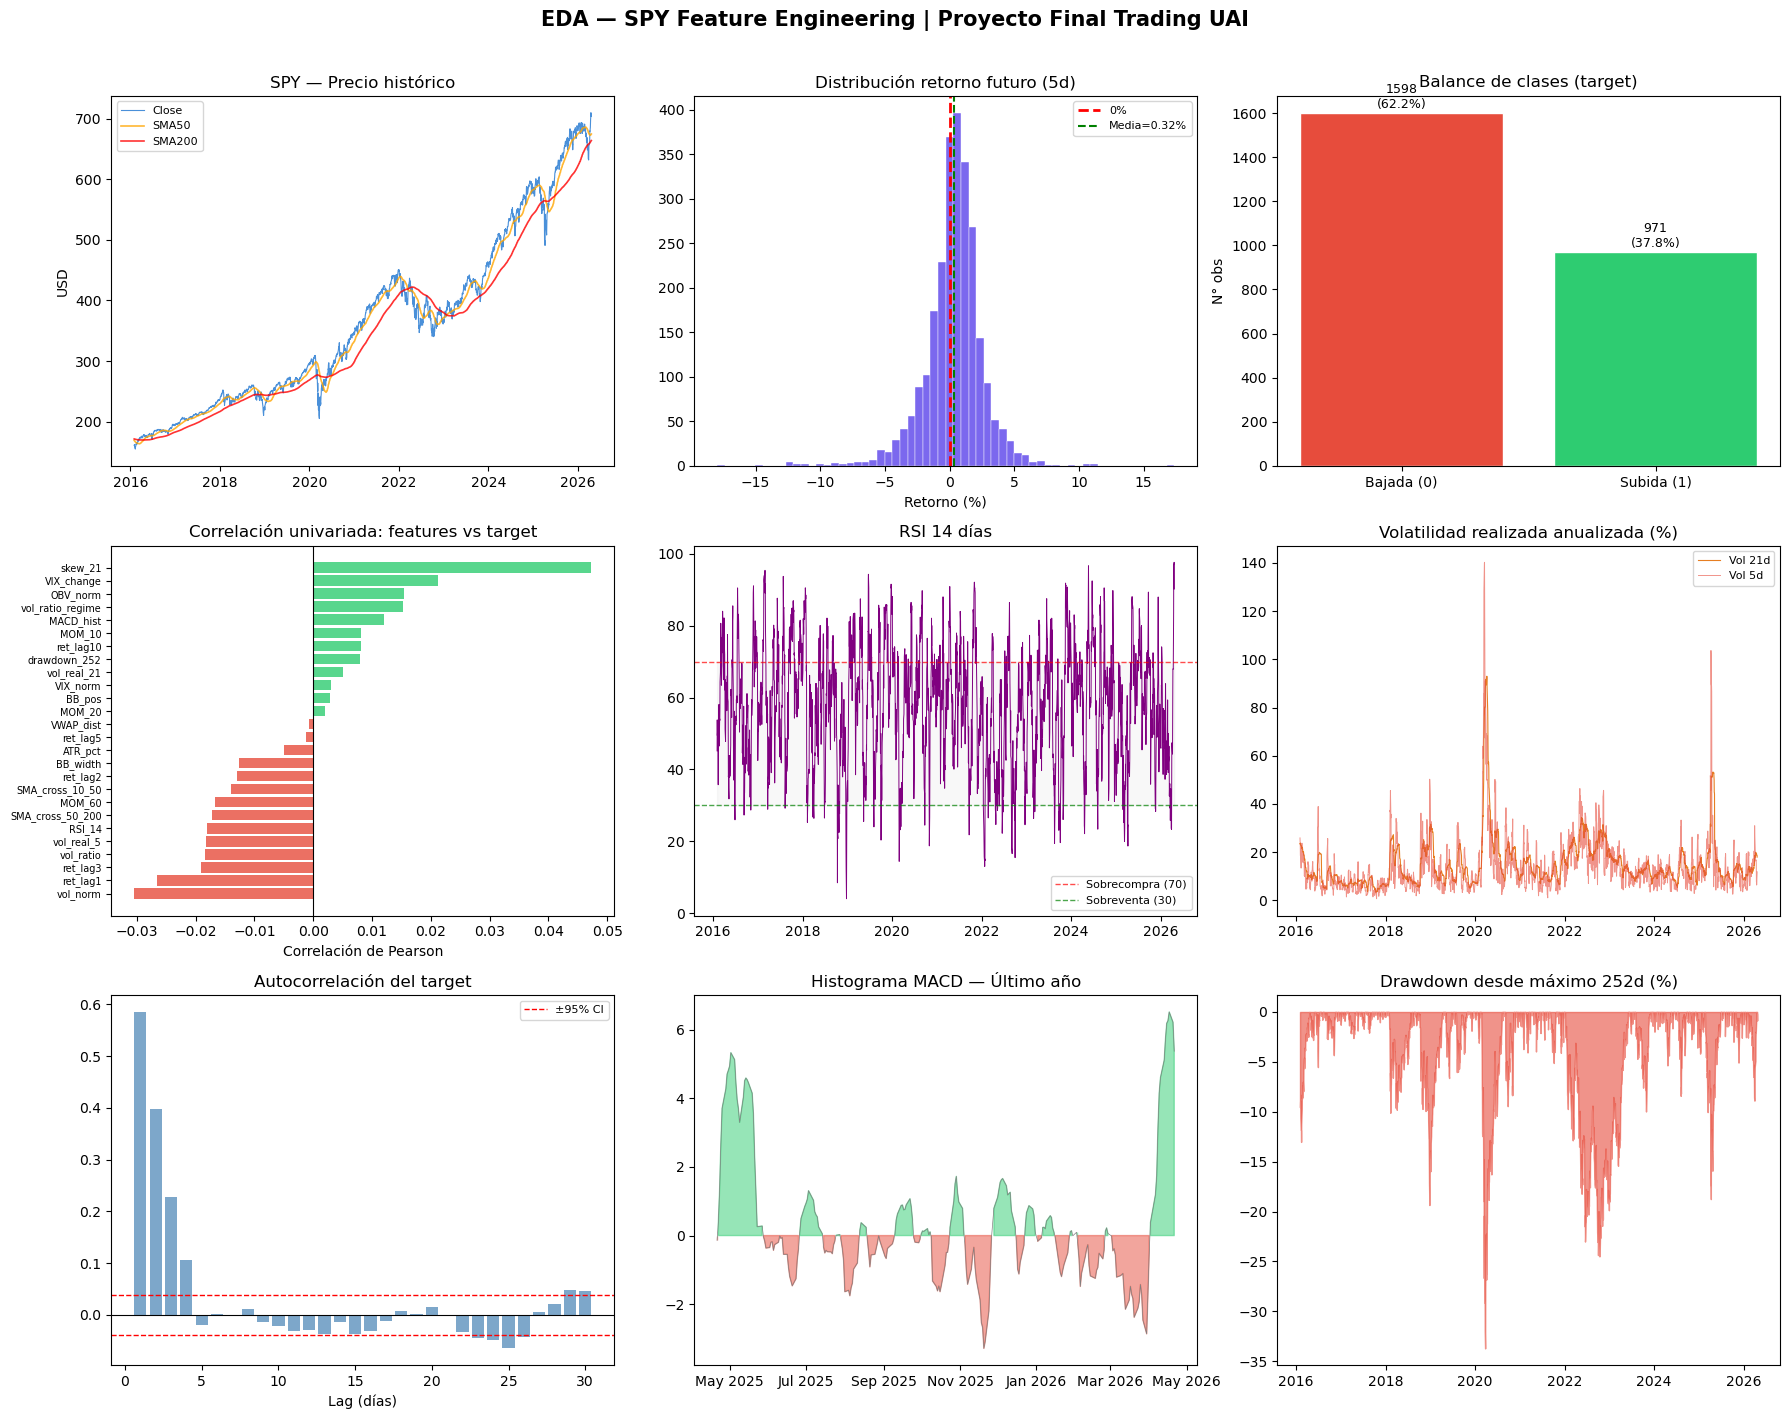

✓ Figura guardada: eda_features.png


In [10]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle(f'EDA — {TICKER} Feature Engineering | Proyecto Final Trading UAI', 
             fontsize=15, fontweight='bold', y=1.01)

# 1. Precio histórico + SMAs
ax = axes[0,0]
ax.plot(df_clean.index, df_clean['Close'], color='#4A90D9', lw=0.8, label='Close')
ax.plot(df_clean.index, df['Close'].rolling(50).mean().reindex(df_clean.index), 
        color='orange', lw=1.2, alpha=0.8, label='SMA50')
ax.plot(df_clean.index, df['Close'].rolling(200).mean().reindex(df_clean.index), 
        color='red', lw=1.2, alpha=0.8, label='SMA200')
ax.set_title('SPY — Precio histórico')
ax.legend(fontsize=8); ax.set_ylabel('USD')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 2. Distribución retorno futuro
ax = axes[0,1]
ax.hist(df_clean['fwd_return']*100, bins=60, color='#7B68EE', edgecolor='white', lw=0.3)
ax.axvline(0, color='red', lw=2, linestyle='--', label='0%')
ax.axvline(df_clean['fwd_return'].mean()*100, color='green', lw=1.5, linestyle='--',
           label=f'Media={df_clean["fwd_return"].mean()*100:.2f}%')
ax.set_title(f'Distribución retorno futuro ({HORIZONTE}d)')
ax.set_xlabel('Retorno (%)'); ax.legend(fontsize=8)

# 3. Balance de clases
ax = axes[0,2]
cnts = df_clean['target'].value_counts()
bars = ax.bar(['Bajada (0)', 'Subida (1)'], cnts.values, color=['#E74C3C','#2ECC71'], edgecolor='white')
for bar, v in zip(bars, cnts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
            f'{v}\n({v/len(df_clean):.1%})', ha='center', va='bottom', fontsize=9)
ax.set_title('Balance de clases (target)'); ax.set_ylabel('N° obs')

# 4. Correlación univariada features vs target
ax = axes[1,0]
corr_tgt = df_clean[FEATURE_COLS+['target']].corr()['target'].drop('target').sort_values()
colors = ['#E74C3C' if v < 0 else '#2ECC71' for v in corr_tgt.values]
ax.barh(range(len(corr_tgt)), corr_tgt.values, color=colors, alpha=0.8)
ax.set_yticks(range(len(corr_tgt))); ax.set_yticklabels(corr_tgt.index, fontsize=7)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Correlación univariada: features vs target')
ax.set_xlabel('Correlación de Pearson')

# 5. RSI histórico
ax = axes[1,1]
ax.plot(df_clean.index, df_clean['RSI_14'], color='purple', lw=0.7)
ax.axhline(70, color='red', lw=1, ls='--', alpha=0.7, label='Sobrecompra (70)')
ax.axhline(30, color='green', lw=1, ls='--', alpha=0.7, label='Sobreventa (30)')
ax.fill_between(df_clean.index, 30, 70, alpha=0.05, color='gray')
ax.set_title('RSI 14 días'); ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 6. Volatilidad realizada
ax = axes[1,2]
ax.plot(df_clean.index, df_clean['vol_real_21']*100, color='#E67E22', lw=0.8, label='Vol 21d')
ax.plot(df_clean.index, df_clean['vol_real_5']*100, color='#E74C3C', lw=0.7, alpha=0.6, label='Vol 5d')
ax.set_title('Volatilidad realizada anualizada (%)'); ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 7. Autocorrelación del target
ax = axes[2,0]
lags = range(1, 31)
acf  = [df_clean['target'].autocorr(lag=l) for l in lags]
ax.bar(lags, acf, color='steelblue', alpha=0.7)
ci = 1.96 / np.sqrt(len(df_clean))
ax.axhline(ci, color='red', lw=1, ls='--', label=f'±95% CI')
ax.axhline(-ci, color='red', lw=1, ls='--')
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Autocorrelación del target'); ax.set_xlabel('Lag (días)'); ax.legend(fontsize=8)

# 8. MACD último año
ax = axes[2,1]
last_yr = df_clean.iloc[-252:]
ax.plot(last_yr.index, last_yr['MACD_hist'], color='gray', lw=0.5)
ax.fill_between(last_yr.index, last_yr['MACD_hist'], 0,
                where=last_yr['MACD_hist'] >= 0, color='#2ECC71', alpha=0.5)
ax.fill_between(last_yr.index, last_yr['MACD_hist'], 0,
                where=last_yr['MACD_hist'] < 0, color='#E74C3C', alpha=0.5)
ax.set_title('Histograma MACD — Último año')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# 9. Drawdown
ax = axes[2,2]
ax.fill_between(df_clean.index, df_clean['drawdown_252']*100, 0, color='#E74C3C', alpha=0.6)
ax.set_title('Drawdown desde máximo 252d (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('eda_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figura guardada: eda_features.png")


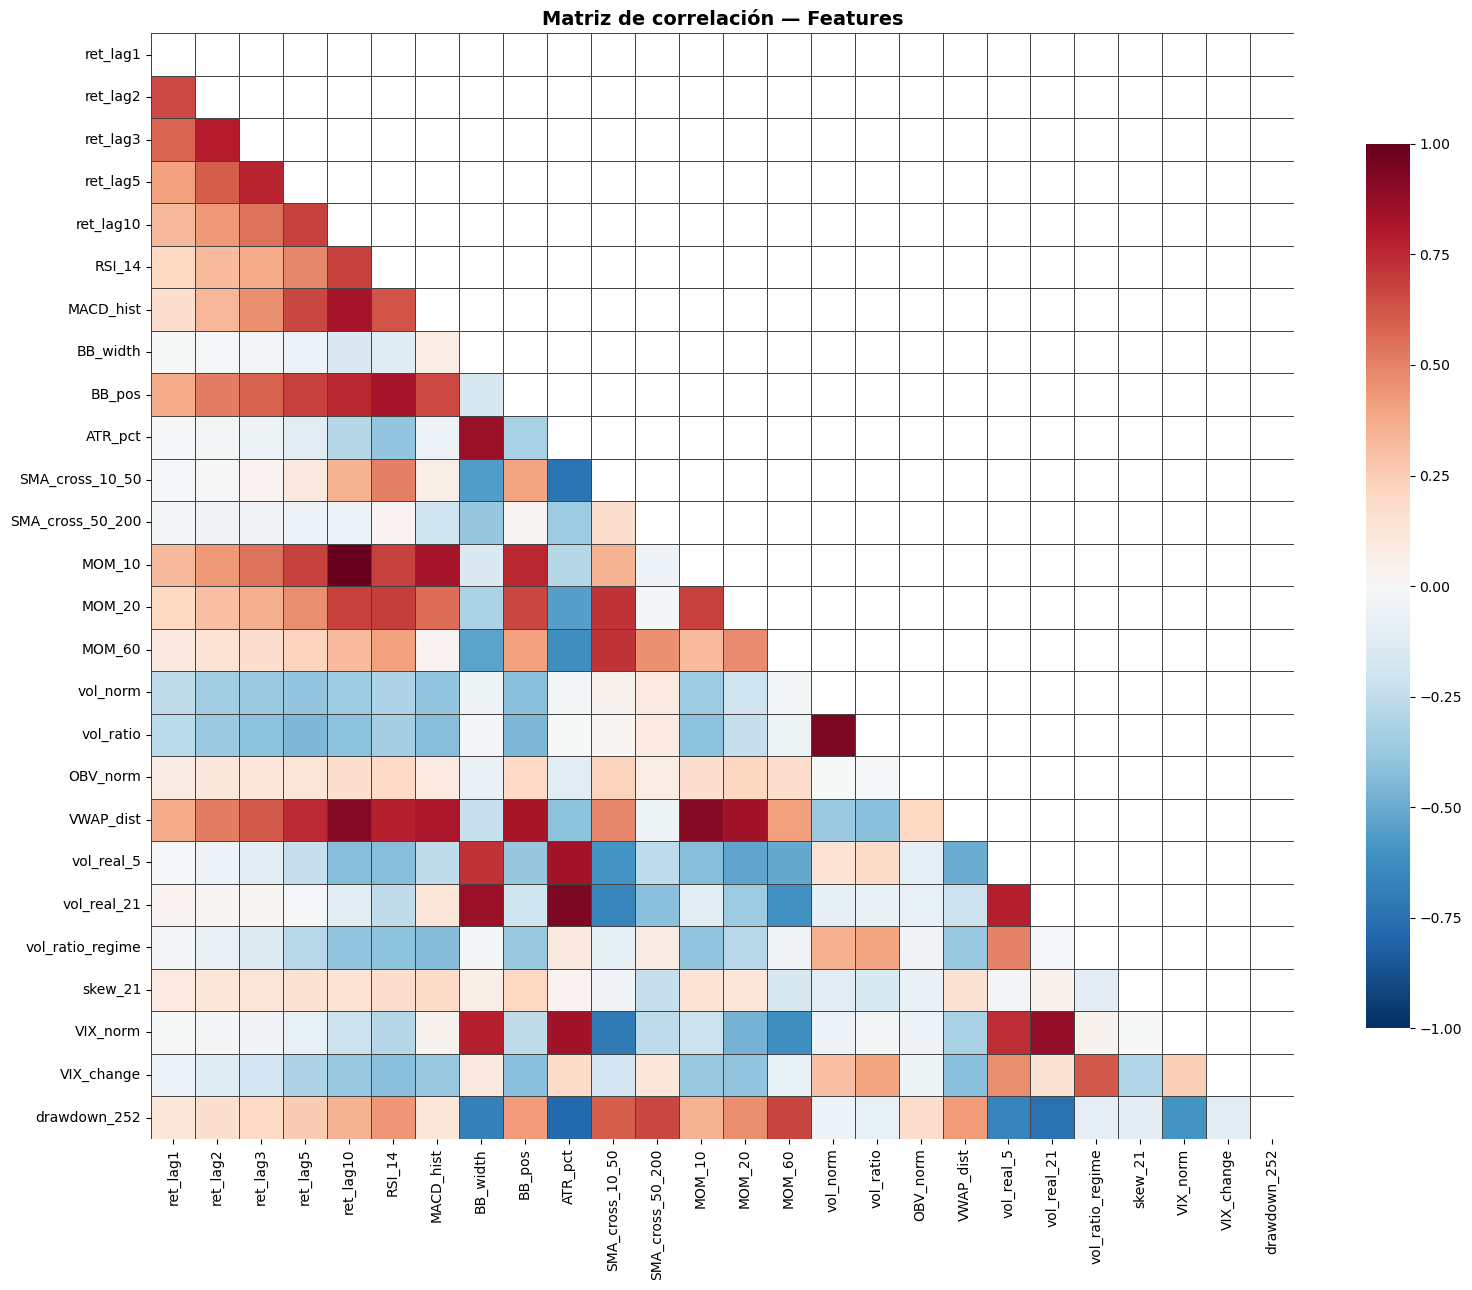

✓ Figura guardada: heatmap_correlaciones.png


In [11]:
# Heatmap de correlaciones entre features
fig2, ax = plt.subplots(figsize=(16, 13))
corr_matrix = df_clean[FEATURE_COLS].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax, cbar_kws={'shrink': 0.8}, linewidths=0.5, linecolor='#444')
ax.set_title('Matriz de correlación — Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figura guardada: heatmap_correlaciones.png")


## 7. Estadísticas descriptivas y resumen

In [12]:
print("="*65)
print("RESUMEN ESTADÍSTICO — FEATURES")
print("="*65)
print(f"Período: {df_clean.index[0].date()} → {df_clean.index[-1].date()}")
print(f"Observaciones totales: {len(df_clean):,}")
print(f"N° features: {len(FEATURE_COLS)}")
print(f"Horizonte predicción: {HORIZONTE} días")
print()
print(df_clean[FEATURE_COLS].describe().T[['mean','std','min','25%','50%','75%','max']].round(4))


RESUMEN ESTADÍSTICO — FEATURES
Período: 2016-02-02 → 2026-04-21
Observaciones totales: 2,569
N° features: 26
Horizonte predicción: 5 días

                      mean       std        min       25%       50%       75%  \
ret_lag1          0.000600  0.011300  -0.109400 -0.003600  0.000700  0.005900   
ret_lag2          0.001200  0.014800  -0.139800 -0.004800  0.002200  0.008700   
ret_lag3          0.001900  0.018300  -0.125800 -0.006200  0.003000  0.011200   
ret_lag5          0.003100  0.023000  -0.179700 -0.006700  0.004600  0.015100   
ret_lag10         0.006200  0.031600  -0.232900 -0.006400  0.008700  0.023500   
RSI_14           57.704200 16.138700   3.989600 46.013500 58.787800 68.985300   
MACD_hist         0.013200  1.284600  -6.361600 -0.475300  0.034200  0.517600   
BB_width          0.063600  0.043900   0.009700  0.037600  0.053300  0.075900   
BB_pos            0.622400  0.312500  -0.448400  0.413500  0.715500  0.860500   
ATR_pct           0.012600  0.007900   0.003400  0.

## 8. Export — features.csv para Notebook E2

In [13]:
# Agregar columna ticker (útil si se expande a multi-activo)
df_clean.index.name = 'date'
df_clean['ticker'] = TICKER

# Guardar CSV
df_clean.to_csv('features.csv')

# Guardar metadata para E2
meta = {
    "ticker": TICKER,
    "start_date": str(df_clean.index[0].date()),
    "end_date": str(df_clean.index[-1].date()),
    "n_obs": len(df_clean),
    "n_features": len(FEATURE_COLS),
    "feature_cols": FEATURE_COLS,
    "target_col": "target",
    "fwd_return_col": "fwd_return",
    "horizonte_dias": HORIZONTE,
    "balance_clase_0": float((df_clean['target']==0).mean()),
    "balance_clase_1": float((df_clean['target']==1).mean()),
    "fred_disponible": FRED_OK if 'FRED_OK' in dir() else False,
    "supuestos_data_cleaning": [
        "Datos OHLCV ajustados por splits y dividendos (auto_adjust=True)",
        "Forward fill para datos macro (VIX, yield curve) en días sin dato",
        "Warmup eliminado: primeras ~200 filas (SMA200 y otros indicadores)",
        f"Últimas {HORIZONTE} filas eliminadas (sin retorno futuro disponible)",
        "Normalización NO aplicada — se aplica dentro de cada fold en E2",
        "OBV calculado iterativamente respetando orden temporal estricto",
        f"Embargo implícito: target usa shift(-{HORIZONTE}), sin info futura"
    ]
}

with open('data_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print("✅ PARTE A COMPLETADA")
print(f"   → features.csv: {df_clean.shape[0]} filas × {df_clean.shape[1]} columnas")
print(f"   → data_meta.json: metadata del pipeline")
print(f"   → eda_features.png: visualizaciones EDA")
print(f"   → heatmap_correlaciones.png: correlaciones entre features")
print()
print("📤 Entregar features.csv a compañero para Notebook E2")
print(f"   Features: {FEATURE_COLS}")


✅ PARTE A COMPLETADA
   → features.csv: 2569 filas × 34 columnas
   → data_meta.json: metadata del pipeline
   → eda_features.png: visualizaciones EDA
   → heatmap_correlaciones.png: correlaciones entre features

📤 Entregar features.csv a compañero para Notebook E2
   Features: ['ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag5', 'ret_lag10', 'RSI_14', 'MACD_hist', 'BB_width', 'BB_pos', 'ATR_pct', 'SMA_cross_10_50', 'SMA_cross_50_200', 'MOM_10', 'MOM_20', 'MOM_60', 'vol_norm', 'vol_ratio', 'OBV_norm', 'VWAP_dist', 'vol_real_5', 'vol_real_21', 'vol_ratio_regime', 'skew_21', 'VIX_norm', 'VIX_change', 'drawdown_252']
